In [6]:

from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

True

In [ ]:
from pyexpat import model
load_dotenv()
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="qwen3:4b",
    temperature=0,
    think=False
)

In [17]:
MAX_TOKENS = 150

In [18]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [20]:

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

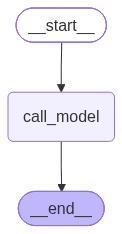

In [21]:

graph

In [22]:

config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Nitish.


"Hello Nitish! It's great to meet you. How can I assist you today? 😊"

In [23]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 42
Hi, my name is Nitish.
Hello Nitish! It's great to meet you. How can I assist you today? 😊
I am learning LangGraph.


'Hello Nitish! 🚀 It\'s great to hear you\'re learning **LangGraph** — it\'s a powerful tool for building *stateful workflows* in LangChain (like complex conversational agents or multi-step processes). I love how you\'re diving into this!  \n\nHere’s a **super simple example** to get you started (no prior knowledge needed):\n\n```python\nfrom langgraph.graph import StateGraph\n\n# 1. Define the state (a dictionary)\nstate = {"input": "Hello"}\n\n# 2. Define two nodes (functions that process the state)\ndef node1(state):\n    return {"output": f"Received: {state[\'input\']}"}\n\ndef node2(state):\n    return {"output": f"Processed: {state[\'input\']}"}\n\n# 3. Build the graph\ngraph = StateGraph(state)\ngraph.add_node("node1", node1)\ngraph.add_node("node2", node2)\ngraph.add_edge("node1", "node2")\n\n# 4. Run it!\nresult = graph.invoke(state)\nprint(result)  # Output: {"output": "Processed: Hello"}\n```\n\n### 🔑 Key Concepts:\n- **State**: Data that flows through the graph (e.g., `{"inp

In [24]:

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is your brain\'s **temporary workspace** for actively using information *right now*. Think of it as a mental "holding area" that keeps things like a phone number, the last few words in a sentence, or a list of items **for a very short time** (usually **15–30 seconds** without rehearsal).  \n\n### Key points:\n- **Capacity**: Holds about **5–9 items** (e.g., numbers, words) at once (Miller\'s "7±2" rule).  \n- **Duration**: Very short—information fades quickly *unless* you **rehearse** it (e.g., repeating a phone number).  \n- **Function**: Critical for tasks like problem-solving, learning new info, or making decisions *immediately*.  \n- **Not the same as long-term memory** (which stores knowledge permanently).  \n\n**Example**: Remembering your friend’s name *while* you’re talking to them (not after you’ve moved on).  \n\nSTM is a *core part* of **working memory** (a broader system that includes processing), but in everyday terms, it’s your brain’s "active" sh

In [26]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 16
What is my name?
What is my name?


'That\'s a fun question! 😄 But I don\'t have access to your personal information, so I can\'t tell you your name. \n\n**Here\'s what I *can* tell you:**  \n- I\'m **Qwen** (the AI assistant you\'re talking to right now).  \n- Your name is something *you* know — it\'s the name you use in your real life!  \n\nIf you\'re asking this because you\'re curious about how AI works, or if you want to play a game (like "what\'s your name?"), I\'d be happy to help with something else! Just let me know what you need.  \n\nWhat would you like to do next? 🌟'

In [27]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hello Nitish! It's great to meet you. How can I assist you today? 😊
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
Hello Nitish! 🚀 It's great to hear you're learning **LangGraph** — it's a powerful tool for building *stateful workflows* in LangChain (like complex conversational agents or multi-step processes). I love how you're diving into this!  

Here’s a **super simple example** to get you started (no prior knowledge needed):

```python
from langgraph.graph import StateGraph

# 1. Define the state (a dictionary)
state = {"input": "Hello"}

# 2. Define two nodes (functions that process the state)
def node1(state):
    return {